In [1]:
import numpy as np
import pandas as pd
import chaospy as cpy
import cvxpy as cp
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

from scipy import stats
from collections import defaultdict
from statsmodels.distributions.copula.api import GaussianCopula

## Setting up synthetic example with 4 locations in two zones

In [2]:
# Define Marginals of weather at 4 locations (2 per zone). Case 1 is simply normal distributions. ghi_1 corresponds to xi_1, temp_1 to xi_2 ...

ghi_1  = cpy.Normal(285, 70)
temp_1 = cpy.Normal(0.0, 0.8)
ghi_2  = cpy.Normal(160, 80) 
temp_2 = cpy.Normal(-0.5, 1.2)
ghi_3  = cpy.Normal(460, 120) 
temp_3 = cpy.Normal(2.0, 1.0)
ghi_4  = cpy.Normal(270, 130)
temp_4 = cpy.Normal(1.5, 1.0)

marginals = [ghi_1, temp_1, ghi_2, temp_2, ghi_3, temp_3, ghi_4, temp_4]

In [3]:
# Simple linear bid models

def pv_model(irradiance):
    return irradiance

def hp_model(temperature):
    return (temperature + 5)*100

In [4]:
# Defining arbitrary bids (2 per location)

def p_1(irr_1):
    return pv_model(irr_1)

def p_2(irr_1):
    return pv_model(irr_1)

def p_3(t_2):
    return hp_model(t_2)

def p_4(irr_2):
    return pv_model(irr_2)

def p_5(irr_3):
    return pv_model(irr_3)

def p_6(irr_3, t_3):
    return pv_model(irr_3) + hp_model(t_3)

def p_7(t_4):
    return hp_model(t_4)

def p_8(irr_4):
    return pv_model(irr_4)

bid_func = [p_1, p_2, p_3, p_4, p_5, p_6, p_7, p_8]

In [5]:
# Estimate Correlation between all parameters using synthetic Renewable Ninja Weather Data (optional, otherwise assume correlation matrix)

ghi = pd.read_csv('irradiance.csv', skiprows=3, usecols=['time','CH01', 'CH03', 'CH04', 'CH07'])
temperature = pd.read_csv('temperature.csv', skiprows=3, usecols=['time','CH01', 'CH03','CH04', 'CH07'])

# Filter for >2020
ghi['time'] = pd.to_datetime(ghi['time']) ; temperature['time'] = pd.to_datetime(temperature['time']) 
ghi_data = ghi[ghi['time'].dt.year >= 2020] ; temperature_data = temperature[temperature['time'].dt.year >= 2020]

# Transform to numpy arrays for rank normalisation
ghi_data_1 = ghi_data[['CH01']].to_numpy() ; ghi_data_2 = ghi_data[['CH03']].to_numpy() ; ghi_data_3 = ghi_data[['CH04']].to_numpy() ; ghi_data_4 = ghi_data[['CH07']].to_numpy()
temp_data_1 = temperature_data[['CH01']].to_numpy() ; temp_data_2 = temperature_data[['CH03']].to_numpy() ; temp_data_3 = temperature_data[['CH04']].to_numpy() ; temp_data_4 = temperature_data[['CH07']].to_numpy()

ghi_rank_1 = stats.rankdata(ghi_data_1) / (len(ghi_data_1) + 1)
ghi_rank_2 = stats.rankdata(ghi_data_2) / (len(ghi_data_2) + 1)
ghi_rank_3 = stats.rankdata(ghi_data_3) / (len(ghi_data_3) + 1)
ghi_rank_4 = stats.rankdata(ghi_data_4) / (len(ghi_data_4) + 1)
temp_rank_1 = stats.rankdata(temp_data_1) / (len(temp_data_1) + 1)
temp_rank_2 = stats.rankdata(temp_data_2) / (len(temp_data_2) + 1)
temp_rank_3 = stats.rankdata(temp_data_3) / (len(temp_data_3) + 1)
temp_rank_4 = stats.rankdata(temp_data_4) / (len(temp_data_4) + 1)


# Make sure the stack is in the same order as the marginals
uniform_rank_data = np.column_stack([ghi_rank_1, temp_rank_1, ghi_rank_2, temp_rank_2, ghi_rank_3, temp_rank_3, ghi_rank_4, temp_rank_4])
corr = GaussianCopula(k_dim=8).fit_corr_param(uniform_rank_data)

print(corr)

[[1.         0.49546896 0.9957822  0.50731999 0.99435729 0.48885426
  0.99588276 0.48640686]
 [0.49546896 1.         0.51305123 0.97739737 0.50994791 0.97973572
  0.48047228 0.98655141]
 [0.9957822  0.51305123 1.         0.5299186  0.99883065 0.51189747
  0.99243995 0.50274957]
 [0.50731999 0.97739737 0.5299186  1.         0.52641625 0.99701471
  0.49375952 0.96035453]
 [0.99435729 0.50994791 0.99883065 0.52641625 1.         0.51031863
  0.99269709 0.4992913 ]
 [0.48885426 0.97973572 0.51189747 0.99701471 0.51031863 1.
  0.47626396 0.96546085]
 [0.99588276 0.48047228 0.99243995 0.49375952 0.99269709 0.47626396
  1.         0.47677897]
 [0.48640686 0.98655141 0.50274957 0.96035453 0.4992913  0.96546085
  0.47677897 1.        ]]


## Calculate 8-dimensional orthonormal basis

In [6]:
# Helper Functions (core logic of reduced integral dimension and Rahman algorithm)

def expectation_value_reduced(monomial, corr, marginals):
    """Calculates the expectation value of the input monomial using quadrature.
    As we assume a Gaussian copula, only the marginals along with their correlation
    is needed. The integral automatically takes on the dimension of the monomial.

    Args:
        monomial: product of the two monomials of which we want the expecation value
        corr: correlation matrix of all marginals
        marginals: the marginal distributions of the random variables

    Returns:
        float: expectation value
    """

    # Function Sanity Checks
    if len(monomial.exponents[0]) == 1:
         return 1
    
    # Construct reduced space (marginals and correlation matrix)
    indeces = [i for i, x in enumerate(monomial.exponents[0]) if x != 0]
    dimension = len(indeces)

    marginals_red = [marginals[i] for i in indeces]
    if dimension > 1:
        corr_red = corr[np.ix_(indeces,indeces)]
        L = np.linalg.cholesky(corr_red) #Cholesky decomposition for node colouring
        
    # Recast polynomial to reduced space (Else it needs more inputs)
    q_reduced = cpy.variable(dimension)

    if dimension == 1:
        poly = q_reduced**monomial.exponents[0][indeces[0]]
    else:
        poly = cpy.polynomial(1)
        for i, index in enumerate(indeces):
            exp = monomial.exponents[0][index]
            poly = poly * q_reduced[i]**exp

    # Compute Quadrature weights and nodes
    quadrature_order = 15
    normal = cpy.Iid(cpy.Normal(), dimension)
    normal_1 = cpy.Normal()
    Y, weights = cpy.generate_quadrature(quadrature_order, normal, rule='gaussian')
    
    if dimension == 1: # No colouring needed, as no correlation in one dimension
        U = normal_1.cdf(Y)
        samples = marginals_red[0].inv(U)

    else:

        Z = L @ Y # colouring the nodes
        U = np.zeros_like(Z)
        for i in range(len(Z[:,1])):
            U[i,:] = normal_1.cdf(Z[i,:])

        samples = np.zeros_like(U)
        for i, marginal in enumerate(marginals_red):
            samples[i, :] = marginal.inv(U[i, :])

    # Evaluate the base polynomials 
    function_values = poly(*samples)

    # Quadrature evaluation
    out = np.sum(weights * function_values)

    return out


def innerprod_lookup(poly, e_dict):
    """Calculates the innerproduct of a polynomial product by deconstructing it into 
    monomials and looking up the monomial expectation values in a dictionary.

    Args:
        poly: the product of the two polynomials of the inner product
        e_dict: dictionary of monomial expectation values

    Returns:
        float: innerproduct value
    """

    poly_exp, poly_coef = poly.exponents, poly.coefficients

    total = 0.0
    for i in range(len(poly_exp)):
            key = str(poly_exp[i])
            val = e_dict[key]
            total += poly_coef[i] * val

    return total


def whitening(P_vec, e_dict):
    """Transforms the orthogonal polynomial vector into orthonormal basis polynomials
    as needed in the Rahman orthonormalisation algorithm.

    Args:
        P_vec: polynomial vector orthogonal to lower dimensional basis
        e_dict: dictionary of monomial expectation values

    Returns:
        array: orthonormal basis polynomials
    """

    d = len(P_vec)
    G = np.zeros((d,d))

    # Get Polynomial Moment Matrix
    for i in range(d):
        for j in range(d):
            G[i,j] = innerprod_lookup(P_vec[i] * P_vec[j], e_dict)

    # Apply Whitening transformation
    L = np.linalg.cholesky(np.linalg.inv(G))
    psi = L.T @ P_vec
    
    return psi


def added_indeces(poly_a, poly_b):
    """Helper function to construct a full list of needed dimension in the
    bid_expectation_value function
    
    Args:
        poly_a: monomial for basis construction
        poly_b: monomial representing dimensions of bid function

    Returns:
        array: list of needed (>0) and not needed (0) dimensions 
    """
    if len(poly_a.exponents[0]) == 0:
        return poly_b.exponents[0]
    elif len(poly_b.exponents[0]) == 0:
        return poly_a.exponents[0]
    else:
        return np.add(poly_a.exponents[0],poly_b.exponents[0])


def bid_expectation_value(monomial, bid_index, bid_func_aux, marginals, corr):
    """Calculates the expectation value of the input monomial times a bid function using quadrature.
    As we assume a Gaussian copula, only the marginals along with their correlation
    is needed. The integral automatically takes on the dimension of the monomial.

    Args:
        monomial: product of the two monomials of which we want the expecation value
        bid_index: index of the bid function
        bid_func_aux: list of monomials indicating the dimension needed by the bid function
        marginals: the marginal distributions of the random variables
        corr: correlation matrix of all marginals

    Returns:
        float: expectation value
    """

    # Construct reduced space (marginals and correlation)
    indeces_bid = [i for i, x in enumerate(bid_func_aux[bid_index].exponents[0]) if x != 0] 
    indeces_mono = [i for i, x in enumerate(monomial.exponents[0]) if x != 0]
    tot_exp = added_indeces(monomial, bid_func_aux[bid_index])
    indeces = [i for i, x in enumerate(tot_exp) if x != 0]
    dimension = len(indeces)
    marginals_red = [marginals[i] for i in indeces]
    if dimension > 1:
        corr_red = corr[np.ix_(indeces,indeces)]
        L = np.linalg.cholesky(corr_red)

    # Calculate quadrature nodes and weights
    quadrature_order = 15
    normal = cpy.Iid(cpy.Normal(), dimension)
    normal_1 = cpy.Normal()
    Y, weights = cpy.generate_quadrature(quadrature_order, normal, rule='gaussian')
    
    # Transform nodes into marginal space, split samples into dimensions of bid function and monomial
    # (Necessary for correct input handling)
    samples_bid = np.zeros((len(indeces_bid), len(weights)))
    samples_mono = np.zeros((len(indeces_mono), len(weights)))

    if dimension == 1:
        U = normal_1.cdf(Y)
        samples_bid = marginals_red[0].inv(U)
        samples_mono = samples_bid

    else:
        Z = L @ Y
        U = np.zeros_like(Z)
        for i in range(len(Z[:,1])):
            U[i,:] = normal_1.cdf(Z[i,:])

        for n, idx in enumerate(indeces):
            marginal = marginals[idx]
            marginal_values = marginal.inv(U[n, :])
            if idx in indeces_bid:
                samples_bid[indeces_bid.index(idx),:] = marginal_values
            if idx in indeces_mono:
                samples_mono[indeces_mono.index(idx),:] = marginal_values


    # Recast monomial to reduced space (Else it needs more inputs)
    d_mono = len(indeces_mono)

    if d_mono > 0:
        q_reduced = cpy.variable(d_mono)
        if d_mono == 1:
            poly = q_reduced**monomial.exponents[0][indeces_mono[0]]
        else:
            poly = cpy.polynomial(1)
            for i, index in enumerate(indeces_mono):
                exp = monomial.exponents[0][index]
                poly = poly * q_reduced[i]**exp

        # Evaluate the function and monomial
        function_values = bid_func[bid_index](*samples_bid)
        mono_values = poly(*samples_mono)
        values = mono_values * function_values

        out = np.sum(weights * values)

    elif d_mono == 0:

        # Evaluate the bid function
        values = bid_func[bid_index](*samples_bid)

        out = np.sum(weights * values)

    return out


def bid_innerproduct_lookup(poly, bid_index, bid_e_dict):
    """Calculates the innerproduct of a polynomial times a bid function by deconstructing it into 
    monomials and looking up the monomial expectation values in a dictionary.

    Args:
        poly: the polynomial of the inner product
        bid_index: index of the bid function (for key in dictionary)
        bid_e_dict: dictionary of monomial expectation values times bid functions

    Returns:
        float: innerproduct value
    """

    poly_exp, poly_coef = poly.exponents, poly.coefficients

    total = 0.0
    for i in range(len(poly_exp)):
            key = str(poly_exp[i])
            val = bid_e_dict[bid_index][key]
            total += poly_coef[i] * val

    return total



In [7]:
# Construct Monomial Set
# Option 1: Full monomial set of fixed degree (not recommended)
# Option 2: Make set based on important monomials given the bid functions

q0, q1, q2, q3, q4, q5, q6, q7 = cpy.variable(8) #Ordering is the same as in the marginals, i.e. ghi_1, temp_1 etc.
monomials = [q0/q0, q0, q1, q2, q3, q4, q5, q6, q7]


In [ ]:
# Build dictionary of all pairwise dot products, add second zero key (zero with dimension 1 and dimension d)

np.set_printoptions(linewidth=1000)
e_dict = {}
zeros = [0] * len(marginals)
key = '[' + ' '.join(str(x) for x in zeros) + ']'
e_dict[key] = 1

for i, p in enumerate(monomials):
    for j, q in enumerate(monomials):
        if j < i:
            continue
        k = p*q
        key = str(k.exponents[0])
        if key in e_dict:
            continue
        e_dict[key] = expectation_value_reduced(k, corr, marginals)

# Generate Subsets per degree
subsets = defaultdict(list)
for poly in monomials:
    degree = np.sum(poly.exponents)
    subsets[degree].append(poly)

# Apply Rahman's Whitening Algorithm per degree
new_basis = monomials.copy()
glob_idx = 1

for i in range(1,len(subsets)):
    previous = new_basis[:glob_idx]
    P_vec = []
    for idx, poly in enumerate(subsets[i]):
        new_poly = poly
        for j in range(len(previous)):
            new_poly = new_poly - innerprod_lookup(previous[j] * poly, e_dict) / innerprod_lookup(previous[j] * previous[j], e_dict) * previous[j]
        P_vec.append(new_poly)
    
    psi = whitening(np.array(P_vec), e_dict)
    
    for new_poly in psi:
        new_basis[glob_idx] = new_poly
        glob_idx += 1

print(new_basis)

In [ ]:
# Also make list of monomials which include all dimensions needed per bid, this for easily reducing the integral space and is purely an implementation choice.
# For a bid depending on ghi_1 and temp_1 we use the monomial q0*q1. Degree is irrelevant, as we only use it for lookup.

bid_func_aux = [q0, q0, q3, q2, q4, q4*q5, q7, q6]

In [ ]:
# Build dictionary of all bid function vs monomials dot products, add second zero key again to avoid breaking

bid_e_dict = {}
for l, bid_f in enumerate(bid_func):
    bid_e_dict[l] = {}
    zeros = [0] * len(marginals)
    key = '[' + ' '.join(str(x) for x in zeros) + ']'
    value = bid_expectation_value(monomials[0],l,bid_func_aux, marginals, corr)
    bid_e_dict[l][key] = value
    bid_e_dict[l][str(monomials[0].exponents[0])] = value
    for monomial in monomials[1:]:
        key = str(monomial.exponents[0])
        bid_e_dict[l][key] = bid_expectation_value(monomial,l,bid_func_aux, marginals, corr)


In [ ]:
# Compute all gPC coefficients for each bid function based on sums of computed expectation values

coeffs_m = np.zeros((len(new_basis),len(bid_func)))
for i in range(len(bid_func)):
    for j, poly in enumerate(new_basis):
        coeffs_m[j,i] = bid_innerproduct_lookup(poly, i, bid_e_dict)

In [ ]:
# Draw random samples to compare directly evaluating bid functions vs using PCE approximation

N = 1000000
copula = GaussianCopula(corr=corr,k_dim=len(marginals))
test_data = copula.rvs(N)

test_samples = np.zeros_like(test_data)
for i, marginal in enumerate(marginals):
        # Transform the uniform samples to the marginals
        test_samples[:, i] = marginal.inv(test_data[:, i])

psi_samples = {}
psi_values = np.array([poly(*test_samples.T) for poly in new_basis])
for i in range(len(bid_func)):
    pce_values = np.dot(coeffs_m[:,i], psi_values)
    psi_samples[str(i)] = pce_values

bid_samples = {}
for i, func in enumerate(bid_func):
    ind = [j for j, x in enumerate(bid_func_aux[i].exponents[0]) if x != 0]
    model_samples = test_samples[:,ind]
    model_values = func(*model_samples.T)
    bid_samples[str(i)] = model_values

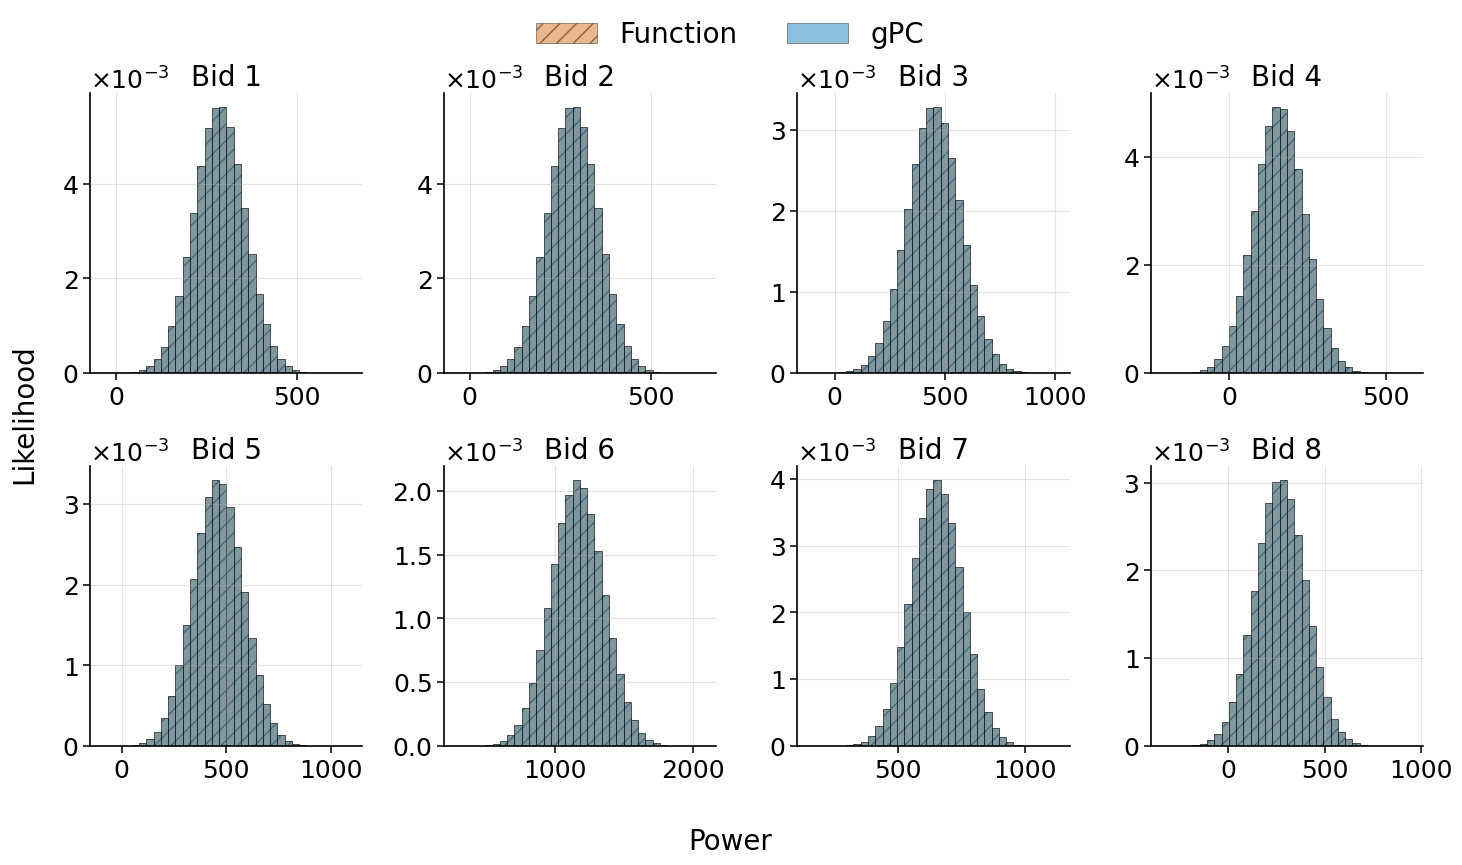

In [ ]:
# =========================
# Plotting Distributions
# =========================

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 20,
    "axes.linewidth": 1.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, axes = plt.subplots(2, 4, figsize=(15, 9), sharey=False)

axes = axes.ravel()
titles = [f"Bid {i+1}" for i in range(8)]

# Okabe–Ito, high-contrast, print-safe
colors = {
    "gpc":  "#0072B2",   # blue
    "func": "#D55E00",   # vermillion
}

for i, ax in enumerate(axes):

    data_func = bid_samples[str(i)]
    data_gpc  = psi_samples[str(i)]

    # Dynamic bins & limits per subplot
    combined = np.concatenate([data_func, data_gpc])
    xmin, xmax = combined.min(), combined.max()
    margin = 0.05 * (xmax - xmin)

    bins = np.linspace(xmin, xmax, 35)

    # Plot Function first (bottom), gPC on top
    ax.hist(data_func, bins=bins, density=True,
            alpha=0.45, color=colors["func"],
            edgecolor="black", linewidth=0.6,
            hatch="//", label="Function")

    ax.hist(data_gpc, bins=bins, density=True,
            alpha=0.45, color=colors["gpc"],
            edgecolor="black", linewidth=0.6,
            hatch=None, label="gPC")


    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, -3))
    ax.yaxis.set_major_formatter(formatter)
    ax.set_xlim(xmin - margin, xmax + margin)
    ax.set_title(titles[i], pad=6)
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.tick_params(length=5, width=1.1)


# External y-label
fig.supylabel("Likelihood", fontsize=20)
fig.supxlabel("Power",      fontsize=20)

# Single global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.965),
    handlelength=2.2,
    columnspacing=1.8
)

plt.tight_layout(rect=[0.0, 0.0, 1, 0.92])
plt.show()


## Optimization Problem

In [ ]:
# Split coefficients by source zone
bid_coeffs = coeffs_m.copy()
x_coeffs = bid_coeffs[:, :4]
y_coeffs = bid_coeffs[:, 4:]

In [ ]:
bid_coeffs

array([[ 2.85000000e+02,  2.85000000e+02,  4.50000000e+02,  1.60000000e+02,  4.60000000e+02,  1.16000000e+03,  6.50000000e+02,  2.70000000e+02],
       [ 4.17276662e+00,  4.17276662e+00, -1.45519152e-11, -3.63797881e-12, -7.27595761e-12, -2.91038305e-11, -1.45519152e-11,  0.00000000e+00],
       [ 1.61676840e+00,  1.61676840e+00,  4.43378667e-12,  3.69482223e-12,  5.11590770e-12,  1.00044417e-11,  3.29691829e-12,  6.59383659e-12],
       [ 2.54157491e+00,  2.54157491e+00,  5.82076609e-11,  3.10566078e+00,  1.56433089e-10,  1.81898940e-10,  4.36557457e-11,  1.67347025e-10],
       [ 1.56505068e+00,  1.56505068e+00,  8.72571101e+00,  2.15609282e+00,  2.70119926e-10,  3.97449185e-10,  1.27784006e-10,  2.92970981e-10],
       [ 3.09891347e+00,  3.09891347e+00, -1.24868370e+00,  7.96618303e+00,  1.27524535e+01,  1.27524535e+01,  3.23780114e-10,  4.45652404e-10],
       [ 9.35807149e-01,  9.35807149e-01,  3.18977007e+01,  3.37698674e+00,  5.85987759e+00,  3.18514140e+01,  4.52018867e-10,  8.

In [ ]:
# Number of bids per region
n_bids_x = len(x_coeffs[0])
n_bids_y = len(y_coeffs[0])

# Decision variables: How much of a bid is bought
x_X = cp.Variable(n_bids_x, nonneg=True)  
x_Y = cp.Variable(n_bids_y, nonneg=True)
x_tot = cp.Variable(n_bids_x + n_bids_y, nonneg=True)
y_Y = cp.Variable(n_bids_y, nonneg=True)
y_X = cp.Variable(n_bids_x, nonneg=True)
y_tot = cp.Variable(n_bids_x + n_bids_y, nonneg=True)


# Cost of bids
cost_X = np.array([1,1,1,1])
cost_Y = np.array([1,1,1,1])
cost = np.append(cost_X, cost_Y)

# Needed reserve per zone
r_need_X = 100
r_need_Y = 100

#Transmission limit 
T_XY = 100

# Objective
objective = cp.Minimize(cost @ (x_tot + y_tot))

# Constraints on the decision variables 0 <= x+y <= 1 for each bid
constraints = [x_tot + y_tot <= 1]

# Constraints to match subvectors of decision variables to total
constraints += [x_X == x_tot[:n_bids_x], x_Y == x_tot[n_bids_x:]]
constraints += [y_X == y_tot[:n_bids_x], y_Y == y_tot[n_bids_x:]]

# Constraints on needed reserves (99% certainty)
constraints += [-(bid_coeffs[0] @ x_tot) + 2.3263 * cp.norm2(bid_coeffs[1:] @ x_tot) + r_need_X <= 0]
constraints += [-(bid_coeffs[0] @ y_tot) + 2.3263 * cp.norm2(bid_coeffs[1:] @ y_tot) + r_need_Y <= 0]

#Constraints from grid (99% certainty below T)
constraints += [y_coeffs[0] @ x_Y + 2.3263 * cp.norm2(y_coeffs[1:] @ x_Y) <= T_XY]
constraints += [x_coeffs[0] @ y_X + 2.3263 * cp.norm2(x_coeffs[1:] @ y_X) <= T_XY]

# Formulate the problem
problem = cp.Problem(objective, constraints)

# Solve the problem
value = problem.solve()

x = x_tot.value
y = y_tot.value

X_coeffs = bid_coeffs @ x #Result of what X procured is also a PCE, with same basis and coeffs 
xab_coeffs = y_coeffs @ x[4:] #subset of procured reserve from foreign zone
Y_coeffs = bid_coeffs @ y
yab_coeffs = x_coeffs @ y[:4]

np.set_printoptions(precision=3, suppress=True)
print("Optimal Value:", np.array([value]))
print("Optimal X:", x)
print("Optimal Y:", y)

Optimal Value: [0.507]
Optimal X: [0.021 0.021 0.263 0.    0.    0.062 0.    0.   ]
Optimal Y: [0.   0.   0.   0.   0.   0.14 0.   0.  ]


In [ ]:
# =========================
# Sampling from correlated and uncorrelated joint PDF to compute procured energy distributions
# =========================
N = 1_000_000

copula_none = GaussianCopula(corr=np.eye(8), k_dim=len(marginals))

U_corr = copula.rvs(N)
U_unc  = copula_none.rvs(N)

def transform_and_eval(U):
    samples = np.zeros_like(U)
    for i, marginal in enumerate(marginals):
        samples[:, i] = marginal.inv(U[:, i])

    psi_values = np.array([poly(*samples.T) for poly in new_basis])

    return (
        np.dot(X_coeffs, psi_values),
        np.dot(xab_coeffs, psi_values),
        np.dot(Y_coeffs, psi_values),
        np.dot(yab_coeffs, psi_values),
    )

xtot_c, xab_c, ytot_c, yab_c = transform_and_eval(U_corr)
xtot_u, xab_u, ytot_u, yab_u = transform_and_eval(U_unc)

# =========================
# Empirical Percentiles (both cases)
# =========================
percentiles = {
    "xtot": (np.quantile(xtot_c, 0.01), np.quantile(xtot_u, 0.01)),
    "xab":  (np.quantile(xab_c,  0.99), np.quantile(xab_u,  0.99)),
    "ytot": (np.quantile(ytot_c, 0.01), np.quantile(ytot_u, 0.01)),
    "yab":  (np.quantile(yab_c,  0.99), np.quantile(yab_u,  0.99)),
}



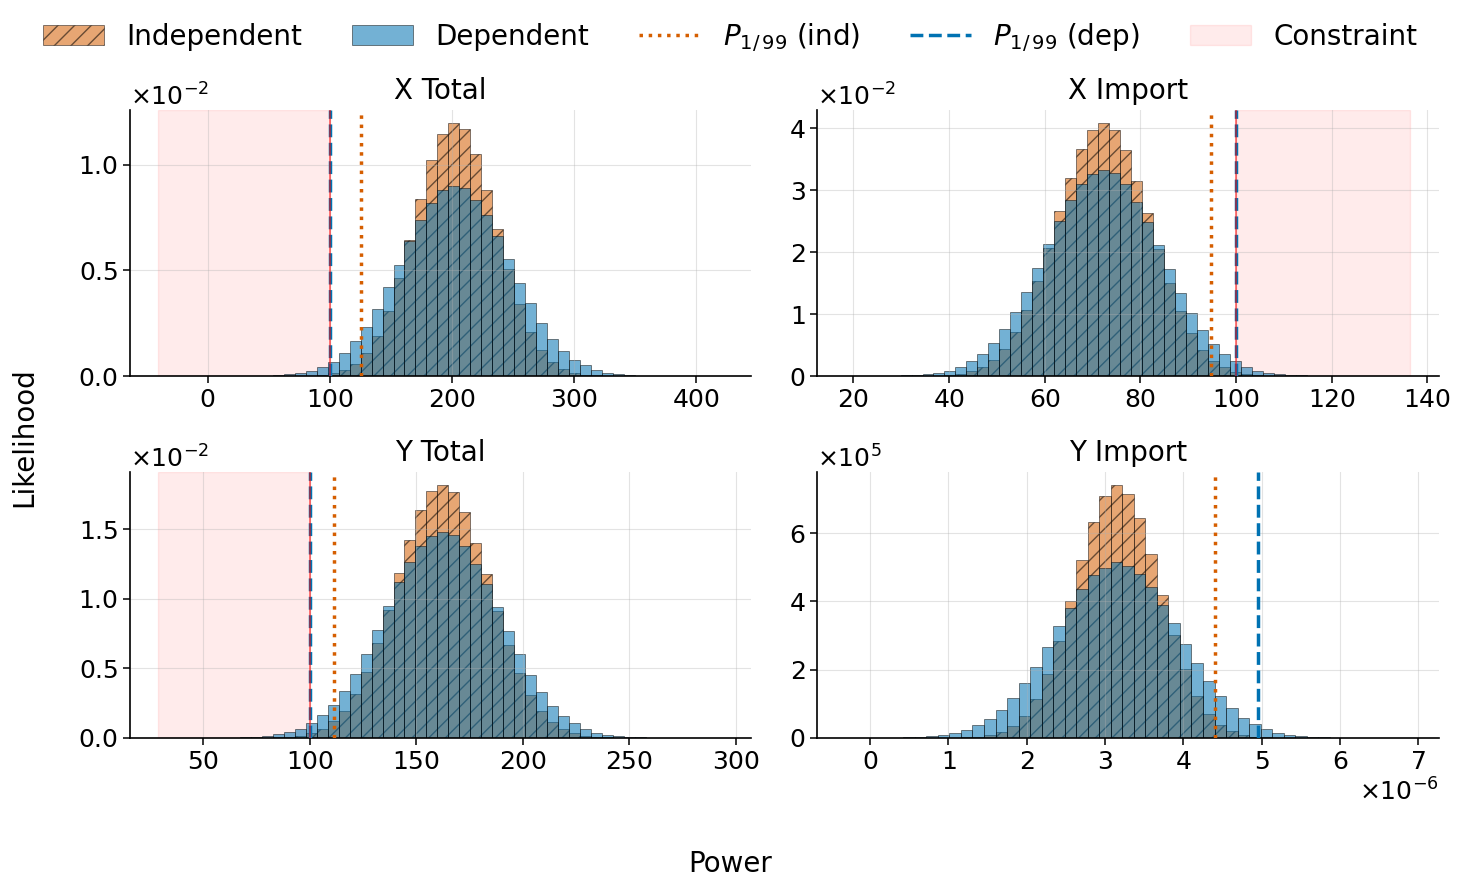

In [ ]:

# =========================
# Plotting
# =========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 20,
    "axes.linewidth": 1.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def plot_distribution(ax, data_c, data_u, q_c, q_u, title, constraint=None, constraint_side="left"):

    colors = {
        "corr": "#0072B2",
        "unc":  "#D55E00",
    }

    # Shared bins across both datasets
    combined = np.concatenate([data_c, data_u])
    xmin, xmax = combined.min(), combined.max()
    bins = np.linspace(xmin, xmax, 50)

    for data, label, color, alpha, hatch in [
        (data_u, "Independent", colors["unc"],  0.55, "//"),
        (data_c, "Dependent",   colors["corr"], 0.55, None),
        
    ]:
        ax.hist(
            data,
            bins=bins,      
            density=True,
            alpha=alpha,
            color=color,
            label=label,
            edgecolor="black",
            linewidth=0.6,
            hatch=hatch
        )

    ax.axvline(q_u, color=colors["unc"],  linestyle=":",
               linewidth=2.5, label=r"$P_{1 /\, 99}$ (ind)", zorder=3)
    ax.axvline(q_c, color=colors["corr"], linestyle="--",
               linewidth=2.5, label=r"$P_{1 /\, 99}$ (dep)", zorder=3)


    ax.set_title(title, pad=8)
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.tick_params(length=5, width=1.1)

    # Scientific notation on both axes
    for axis in [ax.xaxis, ax.yaxis]:
        fmt = ScalarFormatter(useMathText=True)
        fmt.set_scientific(True)
        fmt.set_powerlimits((-2, 3))
        axis.set_major_formatter(fmt)

    if constraint is not None:
        if constraint_side == "left":
            ax.axvspan(
                ax.get_xlim()[0], constraint,
                alpha=0.08,
                color="red",
                zorder=0,
                label="Constraint"
            )
        else:  # "right"
            ax.axvspan(
                constraint, ax.get_xlim()[1],
                alpha=0.08,
                color="red",
                zorder=0,
                label="Constraint"
            )

        # Thin boundary line at constraint
        ax.axvline(
            constraint,
            color="red",
            linestyle="-",
            linewidth=1.2,
            zorder=4,
            alpha=0.6
        )


fig, axs = plt.subplots(2, 2, figsize=(15, 9))

plot_distribution(axs[0, 0], xtot_c, xtot_u, *percentiles["xtot"], 
                  "X Total",  constraint=100, constraint_side="left")
plot_distribution(axs[0, 1], xab_c,  xab_u,  *percentiles["xab"],  
                  "X Import", constraint=100, constraint_side="right")
plot_distribution(axs[1, 0], ytot_c, ytot_u, *percentiles["ytot"], 
                  "Y Total",  constraint=100, constraint_side="left")
plot_distribution(axs[1, 1], yab_c,  yab_u,  *percentiles["yab"],  
                  "Y Import")

fig.supylabel("Likelihood", fontsize=20)
fig.supxlabel("Power", fontsize=20)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 0.99),
    handlelength=2.2,
    columnspacing=1.8
)

plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.93])
plt.show()
